# Calculus for Machine Learning

## Why Calculus?

Calculus is the engine of learning in ML. Every time a neural network trains, it computes **gradients** derivatives of the loss function with respect to every parameter and uses them to update weights. Without calculus, there is no backpropagation, no gradient descent, no learning.

**Key insight:** Training a neural network = minimizing a function using calculus.

---

## Table of Contents
1. Limits & Continuity
2. Derivatives Definition & Rules
3. Partial Derivatives
4. The Gradient
5. Jacobian Matrix
6. Hessian Matrix
7. Directional Derivative
8. Chain Rule The Heart of Backpropagation
9. Taylor Series
10. Integration
11. Automatic Differentiation
12. Backpropagation Derivation

## 1. Limits & Continuity

### Limit
$$\lim_{x \to a} f(x) = L$$

Means: as $x$ approaches $a$, $f(x)$ approaches $L$.

### Continuity
$f$ is continuous at $a$ if:
1. $f(a)$ is defined
2. $\lim_{x \to a} f(x)$ exists
3. $\lim_{x \to a} f(x) = f(a)$

**In ML:** Activation functions must be (sub)differentiable. ReLU is not differentiable at 0, but we use subgradients.

## 2. Derivatives Definition & Rules

### Definition (First Principles)
$$f'(x) = \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**Geometric meaning:** The slope of the tangent line to $f$ at $x$.

### Differentiation Rules

| Rule | Formula |
|------|--------|
| **Power rule** | $\frac{d}{dx} x^n = nx^{n-1}$ |
| **Constant** | $\frac{d}{dx} c = 0$ |
| **Sum rule** | $\frac{d}{dx}[f+g] = f' + g'$ |
| **Product rule** | $\frac{d}{dx}[fg] = f'g + fg'$ |
| **Quotient rule** | $\frac{d}{dx}\left[\frac{f}{g}\right] = \frac{f'g - fg'}{g^2}$ |
| **Chain rule** | $\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$ |
| **Exponential** | $\frac{d}{dx} e^x = e^x$ |
| **Natural log** | $\frac{d}{dx} \ln x = \frac{1}{x}$ |
| **Sigmoid** | $\sigma'(x) = \sigma(x)(1-\sigma(x))$ |
| **tanh** | $\tanh'(x) = 1 - \tanh^2(x)$ |

### Common ML Activation Derivatives

**Sigmoid:** $\sigma(x) = \frac{1}{1+e^{-x}}$, derivative: $\sigma'(x) = \sigma(x)(1-\sigma(x))$

**ReLU:** $f(x) = \max(0, x)$, derivative: $f'(x) = \begin{cases} 1 & x > 0 \\ 0 & x < 0 \end{cases}$

**Softmax:** $\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$, Jacobian: $\frac{\partial s_i}{\partial x_j} = s_i(\delta_{ij} - s_j)$

Analytical derivative at x=2.0: 5.000000
Numerical derivative at x=2.0:  5.000000


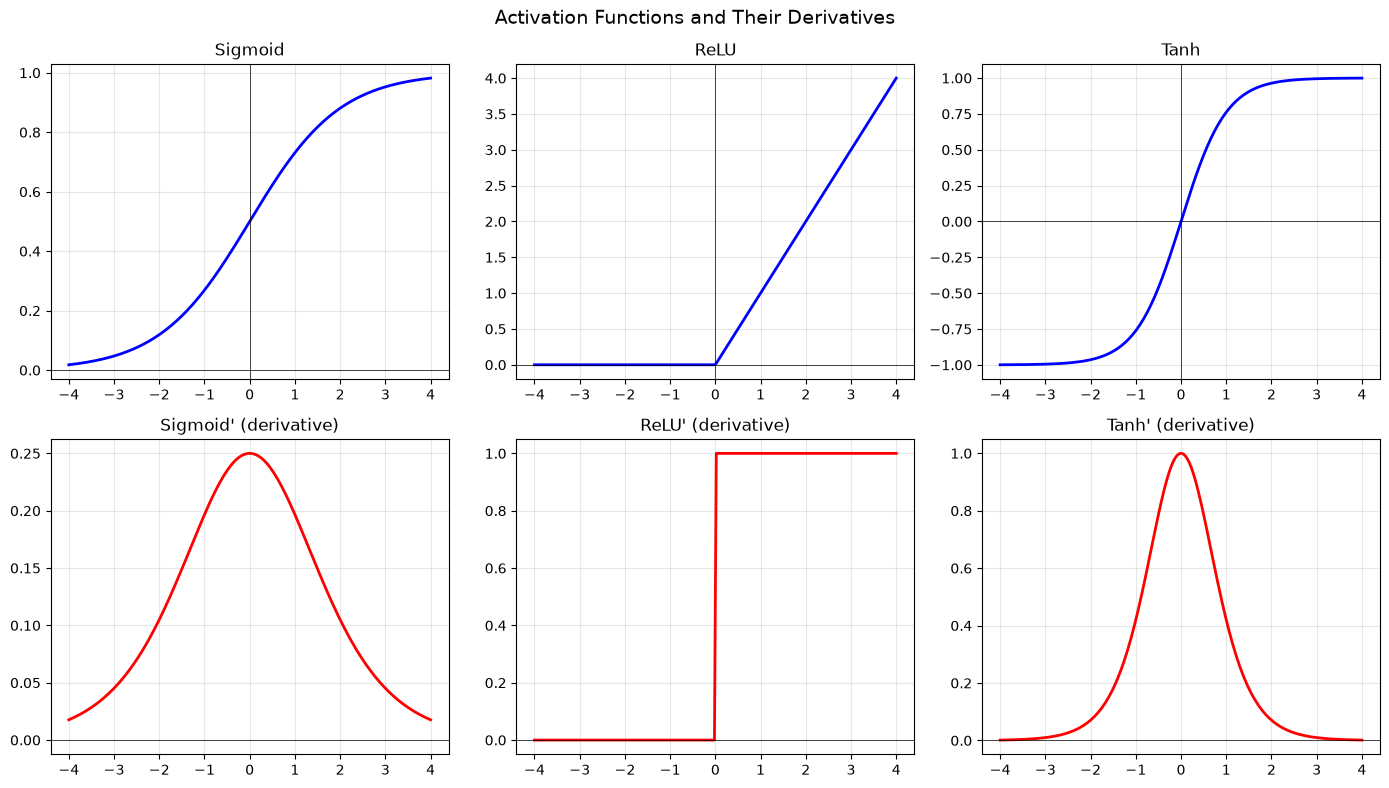

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Numerical derivative (finite differences)
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)  # central difference

# Test functions
f = lambda x: x**3 - 2*x**2 + x
df = lambda x: 3*x**2 - 4*x + 1  # analytical

x = 2.0
print(f"Analytical derivative at x={x}: {df(x):.6f}")
print(f"Numerical derivative at x={x}:  {numerical_derivative(f, x):.6f}")

# Activation functions and their derivatives
x = np.linspace(-4, 4, 200)

def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_prime(x): s = sigmoid(x); return s * (1 - s)
def relu(x): return np.maximum(0, x)
def relu_prime(x): return (x > 0).astype(float)
def tanh_prime(x): return 1 - np.tanh(x)**2
def gelu(x): return x * sigmoid(1.702 * x)  # approx

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
pairs = [
    ('Sigmoid', sigmoid, sigmoid_prime),
    ('ReLU', relu, relu_prime),
    ('Tanh', np.tanh, tanh_prime),
]
for i, (name, fn, dfn) in enumerate(pairs):
    axes[0, i].plot(x, fn(x), 'b-', linewidth=2)
    axes[0, i].set_title(f'{name}')
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axhline(0, color='k', linewidth=0.5)
    axes[0, i].axvline(0, color='k', linewidth=0.5)
    
    axes[1, i].plot(x, dfn(x), 'r-', linewidth=2)
    axes[1, i].set_title(f"{name}' (derivative)")
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].axhline(0, color='k', linewidth=0.5)

plt.suptitle('Activation Functions and Their Derivatives', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Partial Derivatives

For a function $f(x_1, x_2, \ldots, x_n)$, the **partial derivative** with respect to $x_i$ is:
$$\frac{\partial f}{\partial x_i} = \lim_{h \to 0} \frac{f(x_1, \ldots, x_i + h, \ldots, x_n) - f(x_1, \ldots, x_n)}{h}$$

Treat all other variables as constants.

### Example
$f(x, y) = x^2 y + \sin(xy)$

$$\frac{\partial f}{\partial x} = 2xy + y\cos(xy)$$
$$\frac{\partial f}{\partial y} = x^2 + x\cos(xy)$$

### MSE Loss Partial Derivative
Loss $L = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$ where $\hat{y}_i = w x_i + b$:

$$\frac{\partial L}{\partial w} = \frac{-2}{n}\sum_{i=1}^n x_i(y_i - \hat{y}_i)$$
$$\frac{\partial L}{\partial b} = \frac{-2}{n}\sum_{i=1}^n (y_i - \hat{y}_i)$$

In [2]:
import numpy as np

# Partial derivatives numerically
def f(x, y):
    return x**2 * y + np.sin(x * y)

x, y = 1.0, 2.0
h = 1e-5

df_dx = (f(x+h, y) - f(x-h, y)) / (2*h)
df_dy = (f(x, y+h) - f(x, y-h)) / (2*h)
print(f"∂f/∂x at ({x},{y}): {df_dx:.6f}")
print(f"∂f/∂y at ({x},{y}): {df_dy:.6f}")

# Analytical
df_dx_anal = 2*x*y + y*np.cos(x*y)
df_dy_anal = x**2 + x*np.cos(x*y)
print(f"\nAnalytical ∂f/∂x: {df_dx_anal:.6f}")
print(f"Analytical ∂f/∂y: {df_dy_anal:.6f}")

# MSE gradient for linear regression
np.random.seed(0)
n = 50
x_data = np.random.randn(n)
y_data = 2 * x_data + 1 + 0.1*np.random.randn(n)

w, b = 0.0, 0.0
lr = 0.1
for step in range(200):
    y_pred = w * x_data + b
    residuals = y_data - y_pred
    dw = -2/n * np.dot(x_data, residuals)
    db = -2/n * np.sum(residuals)
    w -= lr * dw
    b -= lr * db

print(f"\nLinear regression (gradient descent): w={w:.4f}, b={b:.4f}")
print(f"True values: w=2.0, b=1.0")

∂f/∂x at (1.0,2.0): 3.167706
∂f/∂y at (1.0,2.0): 0.583853

Analytical ∂f/∂x: 3.167706
Analytical ∂f/∂y: 0.583853

Linear regression (gradient descent): w=1.9954, b=0.9985
True values: w=2.0, b=1.0


## 4. The Gradient

The **gradient** of a scalar function $f: \mathbb{R}^n \to \mathbb{R}$ is the vector of all partial derivatives:
$$\nabla f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$$

**Key properties:**
- Points in the direction of **steepest ascent**
- Its negative $-\nabla f$ points in the direction of **steepest descent**
- $\|\nabla f(\mathbf{x})\| = 0$ at local minima, maxima, and saddle points

### Gradient Descent Update Rule
$$\mathbf{x}_{t+1} = \mathbf{x}_t - \alpha \nabla f(\mathbf{x}_t)$$

where $\alpha > 0$ is the **learning rate**.

### Gradient of Common ML Losses

**MSE:** $L = \frac{1}{n}\|\mathbf{y} - X\mathbf{w}\|_2^2$
$$\nabla_\mathbf{w} L = \frac{-2}{n} X^T (\mathbf{y} - X\mathbf{w})$$

**Cross-entropy:** $L = -\sum_i y_i \log(\hat{y}_i)$ (with softmax)
$$\nabla_{\mathbf{z}} L = \hat{\mathbf{y}} - \mathbf{y}$$

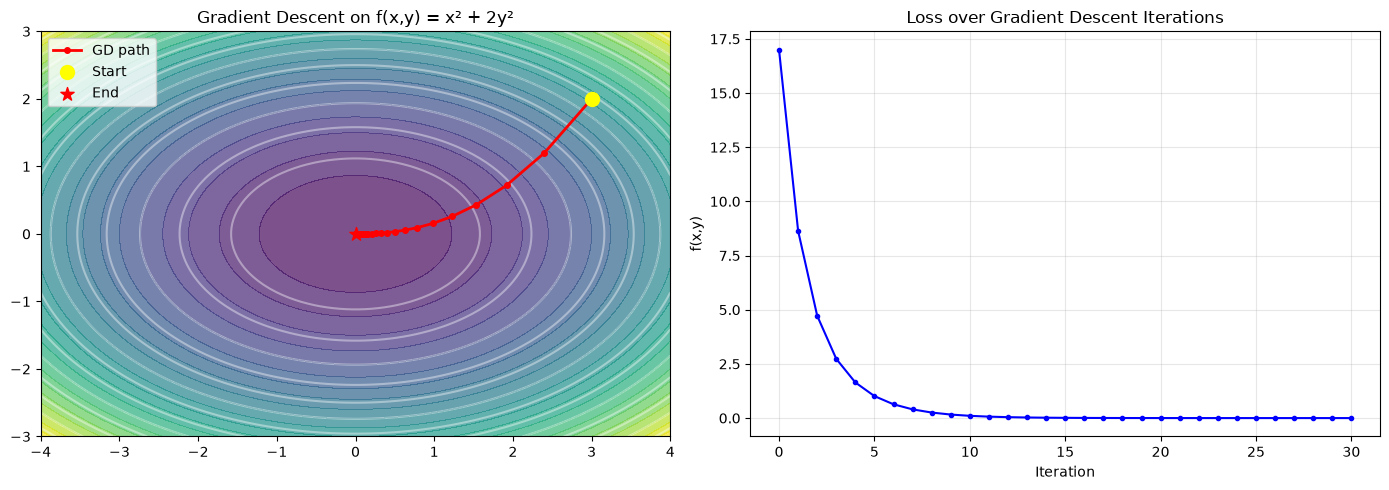

Final position: (0.003714, 0.000000), Loss: 0.00001379


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize gradient on 2D surface
def f(x, y):
    return x**2 + 2*y**2  # elliptic paraboloid

def grad_f(x, y):
    return np.array([2*x, 4*y])

# Gradient descent
x, y = 3.0, 2.0
lr = 0.1
path = [(x, y)]
for _ in range(30):
    g = grad_f(x, y)
    x -= lr * g[0]
    y -= lr * g[1]
    path.append((x, y))

path = np.array(path)

# Plot
X_grid, Y_grid = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-3, 3, 100))
Z = f(X_grid, Y_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour plot with gradient descent path
axes[0].contourf(X_grid, Y_grid, Z, levels=30, cmap='viridis', alpha=0.7)
axes[0].contour(X_grid, Y_grid, Z, levels=15, colors='white', alpha=0.4)
axes[0].plot(path[:,0], path[:,1], 'ro-', markersize=4, linewidth=2, label='GD path')
axes[0].scatter(*path[0], c='yellow', s=100, zorder=5, label='Start')
axes[0].scatter(*path[-1], c='red', s=100, marker='*', zorder=5, label='End')
axes[0].set_title('Gradient Descent on f(x,y) = x² + 2y²')
axes[0].legend()

# Loss curve
losses = [f(p[0], p[1]) for p in path]
axes[1].plot(losses, 'b-o', markersize=3)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('f(x,y)')
axes[1].set_title('Loss over Gradient Descent Iterations')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final position: ({x:.6f}, {y:.6f}), Loss: {f(x,y):.8f}")

## 5. Jacobian Matrix

For a vector-valued function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the **Jacobian** is an $m \times n$ matrix of all partial derivatives:
$$J = \frac{\partial \mathbf{f}}{\partial \mathbf{x}} = \begin{bmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n} \end{bmatrix}$$

**Geometric meaning:** The Jacobian is the best linear approximation of $\mathbf{f}$ at a point. Its determinant gives the local volume scaling.

**In ML:** Jacobian appears in backpropagation when the layer output is a vector. For a linear layer $\mathbf{y} = W\mathbf{x}$, the Jacobian is $J = W$.

## 6. Hessian Matrix

The **Hessian** of $f: \mathbb{R}^n \to \mathbb{R}$ is the $n \times n$ matrix of second-order partial derivatives:
$$H = \nabla^2 f = \begin{bmatrix} \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots \\ \frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

The Hessian is **symmetric**: $H_{ij} = H_{ji}$ (Schwarz's theorem).

### Second-Order Optimality Conditions
At a critical point $\nabla f = 0$:
- $H$ **positive definite** (all eigenvalues $> 0$) $\Rightarrow$ local minimum
- $H$ **negative definite** (all eigenvalues $< 0$) $\Rightarrow$ local maximum
- $H$ **indefinite** (mixed eigenvalues) $\Rightarrow$ saddle point

**In ML:** The Hessian of the loss surface determines whether we're at a minimum or saddle point. For large NNs, the Hessian is too expensive to compute (millions × millions) hence we use first-order methods (gradient descent).

In [4]:
import numpy as np

# Numerical Hessian
def numerical_hessian(f, x, h=1e-4):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x_pp = x.copy(); x_pp[i] += h; x_pp[j] += h
            x_pm = x.copy(); x_pm[i] += h; x_pm[j] -= h
            x_mp = x.copy(); x_mp[i] -= h; x_mp[j] += h
            x_mm = x.copy(); x_mm[i] -= h; x_mm[j] -= h
            H[i,j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4*h**2)
    return H

f = lambda x: x[0]**2 + 2*x[1]**2 + x[0]*x[1]
x0 = np.array([1.0, 1.0])

H = numerical_hessian(f, x0)
print("Hessian:\n", H)

eigenvalues = np.linalg.eigvalsh(H)
print(f"Eigenvalues: {eigenvalues}")
print(f"All positive? {all(eigenvalues > 0)} → {'local min' if all(eigenvalues > 0) else 'not a min'}")

Hessian:
 [[2.         1.00000001]
 [1.00000001 4.        ]]
Eigenvalues: [1.58578643 4.41421356]
All positive? True → local min


## 7. Directional Derivative

The **directional derivative** of $f$ at $\mathbf{x}$ in direction $\mathbf{u}$ (unit vector):
$$D_{\mathbf{u}} f(\mathbf{x}) = \nabla f(\mathbf{x}) \cdot \mathbf{u} = \|\nabla f(\mathbf{x})\| \cos\theta$$

- **Maximum** when $\mathbf{u} = \frac{\nabla f}{\|\nabla f\|}$ (gradient direction)
- **Minimum** (most negative) when $\mathbf{u} = -\frac{\nabla f}{\|\nabla f\|}$ (steepest descent)
- **Zero** when $\mathbf{u} \perp \nabla f$ (along level curves)

## 8. Chain Rule The Heart of Backpropagation

### Single Variable
If $y = f(g(x))$:
$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx} = f'(g(x)) \cdot g'(x)$$

### Multivariable
If $z = f(x_1(t), x_2(t), \ldots, x_n(t))$:
$$\frac{dz}{dt} = \sum_{i=1}^n \frac{\partial z}{\partial x_i} \frac{dx_i}{dt}$$

### Vector Form (Backpropagation)
For layers $L_1, L_2, \ldots, L_n$ with outputs $\mathbf{a}_1, \mathbf{a}_2, \ldots, \mathbf{a}_n$:
$$\frac{\partial \mathcal{L}}{\partial \mathbf{a}_k} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}_{k+1}} \cdot \frac{\partial \mathbf{a}_{k+1}}{\partial \mathbf{a}_k}$$

This is the **chain rule applied recursively** that's all backpropagation is!

### Two-Layer Network Example
$$\mathbf{z}_1 = W_1 \mathbf{x}, \quad \mathbf{a}_1 = \sigma(\mathbf{z}_1)$$
$$\mathbf{z}_2 = W_2 \mathbf{a}_1, \quad \hat{y} = \sigma(\mathbf{z}_2)$$
$$L = \frac{1}{2}(y - \hat{y})^2$$

Gradient w.r.t. $W_1$:
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial \mathbf{z}_2} \cdot \frac{\partial \mathbf{z}_2}{\partial \mathbf{a}_1} \cdot \frac{\partial \mathbf{a}_1}{\partial \mathbf{z}_1} \cdot \frac{\partial \mathbf{z}_1}{\partial W_1}$$

In [5]:
import numpy as np

# Manual backpropagation for a 2-layer network
np.random.seed(42)

def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def sigmoid_prime(x): s = sigmoid(x); return s * (1 - s)

# Data
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)  # XOR

# Initialize weights
W1 = np.random.randn(2, 4) * 0.1
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.1
b2 = np.zeros((1, 1))

lr = 0.5
losses = []

for epoch in range(5000):
    # Forward pass
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)
    
    # Loss (MSE)
    loss = np.mean((y - y_hat)**2)
    losses.append(loss)
    
    # Backward pass (chain rule)
    dL_dyhat = -2 * (y - y_hat) / len(y)     # ∂L/∂ŷ
    dyhat_dz2 = sigmoid_prime(z2)             # ∂ŷ/∂z2
    delta2 = dL_dyhat * dyhat_dz2             # ∂L/∂z2
    
    dL_dW2 = a1.T @ delta2                    # ∂L/∂W2
    dL_db2 = delta2.sum(axis=0, keepdims=True)
    
    dL_da1 = delta2 @ W2.T                    # ∂L/∂a1
    da1_dz1 = sigmoid_prime(z1)               # ∂a1/∂z1
    delta1 = dL_da1 * da1_dz1                 # ∂L/∂z1
    
    dL_dW1 = X.T @ delta1                     # ∂L/∂W1
    dL_db1 = delta1.sum(axis=0, keepdims=True)
    
    # Gradient descent update
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

print("XOR predictions:")
for xi, yi, pi in zip(X, y, y_hat):
    print(f"  Input: {xi.astype(int)}, True: {int(yi[0])}, Pred: {pi[0]:.3f}")
print(f"Final loss: {losses[-1]:.6f}")

XOR predictions:
  Input: [0 0], True: 0, Pred: 0.500
  Input: [0 1], True: 1, Pred: 0.500
  Input: [1 0], True: 1, Pred: 0.500
  Input: [1 1], True: 0, Pred: 0.500
Final loss: 0.250000


## 9. Taylor Series

Any smooth function $f$ can be approximated near point $a$ by:
$$f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots = \sum_{n=0}^\infty \frac{f^{(n)}(a)}{n!}(x-a)^n$$

**Multivariate Taylor expansion** (around $\mathbf{x}_0$):
$$f(\mathbf{x}) \approx f(\mathbf{x}_0) + \nabla f(\mathbf{x}_0)^T (\mathbf{x} - \mathbf{x}_0) + \frac{1}{2}(\mathbf{x}-\mathbf{x}_0)^T H(\mathbf{x}_0)(\mathbf{x}-\mathbf{x}_0) + \cdots$$

**In ML:**
- **Newton's method** uses the 2nd-order Taylor expansion
- **Adam optimizer** learning rate analysis uses Taylor series
- **Knowledge distillation** uses soft targets related to Taylor approximations of softmax

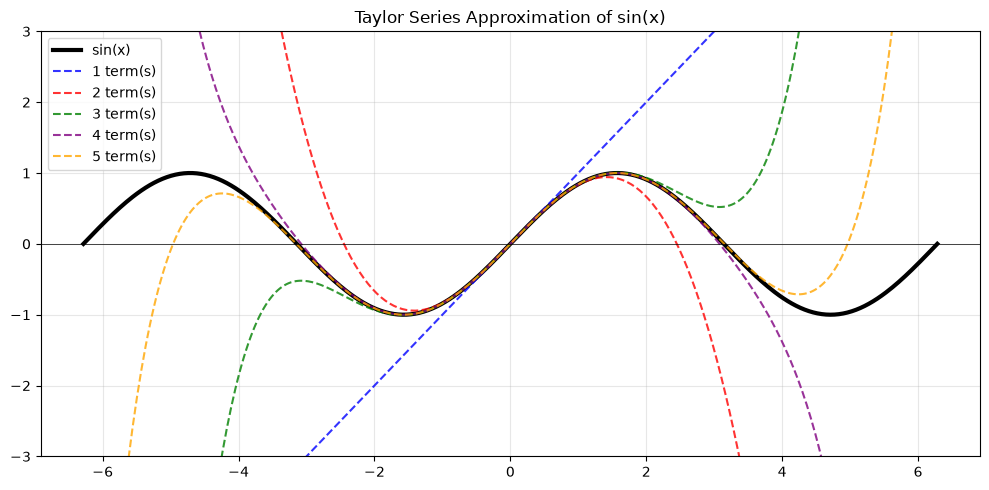

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# Taylor approximation of sin(x) around 0
x = np.linspace(-2*np.pi, 2*np.pi, 400)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, np.sin(x), 'k-', linewidth=3, label='sin(x)')

colors = ['blue', 'red', 'green', 'purple', 'orange']
for n_terms, color in zip([1, 2, 3, 4, 5], colors):
    approx = np.zeros_like(x)
    for k in range(n_terms):
        # sin(x) = x - x^3/3! + x^5/5! - ...
        power = 2*k + 1
        approx += ((-1)**k * x**power) / factorial(power)
    ax.plot(x, approx, '--', color=color, linewidth=1.5, 
            label=f'{n_terms} term(s)', alpha=0.8)

ax.set_ylim(-3, 3)
ax.legend()
ax.set_title('Taylor Series Approximation of sin(x)')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

## 10. Integration

### Definite Integral
$$\int_a^b f(x)\, dx = \lim_{n\to\infty} \sum_{i=1}^n f(x_i^*) \Delta x$$

**Geometric meaning:** Area under the curve from $a$ to $b$.

### Fundamental Theorem of Calculus
If $F'(x) = f(x)$, then:
$$\int_a^b f(x)\, dx = F(b) - F(a)$$

### In ML and Probability
Continuous probability distributions use integrals:
$$P(a \leq X \leq b) = \int_a^b f_X(x)\, dx$$

Expected value:
$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x f_X(x)\, dx$$

**KL divergence** (continuous):
$$D_{KL}(P \| Q) = \int p(x) \log \frac{p(x)}{q(x)}\, dx$$

**ELBO in VAEs:**
$$\text{ELBO} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$

In [7]:
import numpy as np
from scipy import integrate
from scipy.stats import norm

# Numerical integration
f = lambda x: np.exp(-x**2)   # Gaussian kernel
result, error = integrate.quad(f, -np.inf, np.inf)
print(f"∫ e^(-x²) dx from -∞ to ∞ = {result:.6f} (should be √π = {np.sqrt(np.pi):.6f})")

# Normal distribution probability
mu, sigma = 0, 1
prob, _ = integrate.quad(norm.pdf, -1, 1, args=(mu, sigma))
print(f"P(-1 ≤ X ≤ 1) for N(0,1): {prob:.4f} (should be ~68%)")

# Monte Carlo integration
def monte_carlo_integral(f, a, b, n=100000):
    x_samples = np.random.uniform(a, b, n)
    return (b - a) * np.mean(f(x_samples))

f_test = lambda x: x**2
mc_result = monte_carlo_integral(f_test, 0, 1)
print(f"\nMonte Carlo ∫₀¹ x² dx = {mc_result:.4f} (exact = {1/3:.4f})")

∫ e^(-x²) dx from -∞ to ∞ = 1.772454 (should be √π = 1.772454)
P(-1 ≤ X ≤ 1) for N(0,1): 0.6827 (should be ~68%)

Monte Carlo ∫₀¹ x² dx = 0.3326 (exact = 0.3333)


## 11. Automatic Differentiation

Modern deep learning frameworks (PyTorch, JAX, TensorFlow) use **automatic differentiation (autograd)** not numerical differentiation.

### Two modes:
1. **Forward mode:** Computes $\frac{\partial f_i}{\partial x_j}$ for a fixed input $j$. Efficient when $n_{inputs} \ll n_{outputs}$.
2. **Reverse mode (backprop):** Computes $\frac{\partial f_i}{\partial x_j}$ for a fixed output $i$. Efficient when $n_{outputs} \ll n_{inputs}$ this is why ML uses reverse mode.

### Computation Graph
PyTorch builds a **dynamic computation graph** as operations execute. Each node stores the operation and its local gradient.

**Calling `.backward()`** traverses the graph in reverse (backpropagation).

In [8]:
try:
    import torch

    # PyTorch autograd
    x = torch.tensor(2.0, requires_grad=True)
    y = torch.tensor(3.0, requires_grad=True)

    # z = x^2 * y + sin(x*y)
    z = x**2 * y + torch.sin(x * y)
    z.backward()

    print(f"z = x²y + sin(xy) at x=2, y=3: z={z.item():.4f}")
    print(f"∂z/∂x = 2xy + y·cos(xy) = {x.grad.item():.4f}")
    print(f"∂z/∂y = x² + x·cos(xy) = {y.grad.item():.4f}")

    # Analytical check
    xv, yv = 2.0, 3.0
    print(f"Analytical ∂z/∂x = {2*xv*yv + yv*np.cos(xv*yv):.4f}")
    print(f"Analytical ∂z/∂y = {xv**2 + xv*np.cos(xv*yv):.4f}")
    
    # Gradient of a neural network layer
    W = torch.randn(4, 3, requires_grad=True)
    x_in = torch.randn(3)
    loss = (torch.sigmoid(W @ x_in) - torch.ones(4)).pow(2).mean()
    loss.backward()
    print(f"\nGradient of W shape: {W.grad.shape}")
    
except ImportError:
    print("PyTorch not installed. Run: pip install torch")
    print("Demonstrating with numpy instead...")
    
    # Manual autograd with numpy
    x, y = 2.0, 3.0
    dz_dx = 2*x*y + y*np.cos(x*y)
    dz_dy = x**2 + x*np.cos(x*y)
    print(f"∂z/∂x = {dz_dx:.4f}, ∂z/∂y = {dz_dy:.4f}")

z = x²y + sin(xy) at x=2, y=3: z=11.7206
∂z/∂x = 2xy + y·cos(xy) = 14.8805
∂z/∂y = x² + x·cos(xy) = 5.9203
Analytical ∂z/∂x = 14.8805
Analytical ∂z/∂y = 5.9203

Gradient of W shape: torch.Size([4, 3])


## Additional Learning Resources

### Video Courses
- **3Blue1Brown Essence of Calculus** (Best visual intro): https://www.youtube.com/playlist?list=PLZHQObOWTQDMsr9K-rj53DwVRMYO3t5Yr
- **3Blue1Brown Neural Networks** (backprop visually): https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi
- **MIT 18.01 Single Variable Calculus**: https://ocw.mit.edu/courses/18-01-single-variable-calculus-fall-2006/
- **MIT 18.02 Multivariable Calculus**: https://ocw.mit.edu/courses/18-02-multivariable-calculus-fall-2007/
- **Andrej Karpathy Micrograd (backprop from scratch)**: https://www.youtube.com/watch?v=VMj-3S1tku0

### Books
- **Mathematics for Machine Learning (Ch 5 Vector Calculus)**: https://mml-book.github.io/
- **Deep Learning Book Ch 4 (Numerical Computation)**: https://www.deeplearningbook.org/contents/numerical.html
- **Matrix Calculus for Deep Learning**: https://arxiv.org/abs/1802.01528

### Papers
- **Automatic Differentiation in Machine Learning: a Survey**: https://arxiv.org/abs/1502.05767
- **Backpropagation original paper (Rumelhart 1986)**: https://www.nature.com/articles/323533a0

### Interactive
- **Andrej Karpathy's micrograd (autograd engine in 100 lines)**: https://github.com/karpathy/micrograd
- **Khan Academy Calculus**: https://www.khanacademy.org/math/calculus-1